In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
import seaborn as sns


In [2]:
df = pd.read_csv("/kaggle/input/datasets/shree5niraj/listings1/listings1.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,14714,Private room c/ bathroom . Colonia Juarez.,57785,Diego,NaN,Cuauhtémoc,19.43035,-99.15511,Private room,478,2,0,NaN,NaN,2,327
1,22787,"Sunny suite w/ queen size bed, inside boutique...",87973,Diego,NaN,Cuauhtémoc,19.44076,-99.16324,Private room,1969,1,57,2019-05-27,0.52,9,355
2,33681,Couple of Rooms,145672,Edubiel,NaN,Tlalpan,19.27215,-99.21848,Private room,1740,1,0,NaN,NaN,1,365
3,35797,Villa Dante,153786,Dici,NaN,Cuajimalpa de Morelos,19.38399,-99.27335,Entire home/apt,3823,1,0,NaN,NaN,2,363
4,44616,CONDESA HAUS B&B,196253,Condesa Haus Bed & Breakfast CDMX,NaN,Cuauhtémoc,19.41006,-99.17645,Private room,1893,1,39,2019-05-02,0.42,10,334


In [3]:
#The number of rows in this dataset is 19030
#The number of variables is 16 
print("Number of rows: ", len(df))
df.dtypes

Number of rows:  19030


id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [4]:
#All the rows in neighbourhood column are NaN values
print("The following columns have values NaN")
df.isnull().sum()

The following columns have values NaN


id                                    0
name                                 13
host_id                               0
host_name                            62
neighbourhood_group               19030
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                        4808
reviews_per_month                  4808
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [5]:
#Drop columns that shouldn't have meaning in the data.
df.drop(['id', 'host_name', 'last_review'], axis=1, inplace=True)
df.head(5)

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Private room c/ bathroom . Colonia Juarez.,57785,NaN,Cuauhtémoc,19.43035,-99.15511,Private room,478,2,0,NaN,2,327
1,"Sunny suite w/ queen size bed, inside boutique...",87973,NaN,Cuauhtémoc,19.44076,-99.16324,Private room,1969,1,57,0.52,9,355
2,Couple of Rooms,145672,NaN,Tlalpan,19.27215,-99.21848,Private room,1740,1,0,NaN,1,365
3,Villa Dante,153786,NaN,Cuajimalpa de Morelos,19.38399,-99.27335,Entire home/apt,3823,1,0,NaN,2,363
4,CONDESA HAUS B&B,196253,NaN,Cuauhtémoc,19.41006,-99.17645,Private room,1893,1,39,0.42,10,334


In [6]:
#Almost all values in neighbourhood_group is NaN. Drop that column
df = df.drop(columns='neighbourhood_group')
df.head(5)

,name,host_id,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Private room c/ bathroom . Colonia Juarez.,57785,Cuauhtémoc,19.43035,-99.15511,Private room,478,2,0,NaN,2,327
1,"Sunny suite w/ queen size bed, inside boutique...",87973,Cuauhtémoc,19.44076,-99.16324,Private room,1969,1,57,0.52,9,355
2,Couple of Rooms,145672,Tlalpan,19.27215,-99.21848,Private room,1740,1,0,NaN,1,365
3,Villa Dante,153786,Cuajimalpa de Morelos,19.38399,-99.27335,Entire home/apt,3823,1,0,NaN,2,363
4,CONDESA HAUS B&B,196253,Cuauhtémoc,19.41006,-99.17645,Private room,1893,1,39,0.42,10,334


In [7]:
#reviews_per_month can be an important column, but has some NaN values. SO instead of dropping the column, replace all NaN values with 0
df.fillna({'reviews_per_month':0}, inplace=True)
print(df.reviews_per_month.isnull().sum())

0


In [8]:
#column neighbourhood should heavyily influence the other fields. Analyze all the unique neighbourhoods.
print(df.neighbourhood.unique())

['Cuauhtémoc' 'Tlalpan' 'Cuajimalpa de Morelos' 'Coyoacán'
 'Miguel Hidalgo' 'Benito Juárez' 'Azcapotzalco' 'Iztacalco'
 'Venustiano Carranza' 'Iztapalapa' 'Álvaro Obregón' 'Gustavo A. Madero'
 'Xochimilco' 'La Magdalena Contreras' 'Tláhuac' 'Milpa Alta']


In [9]:
#find unique values of room_type, which should also influence the other fields.
print(df.room_type.unique())

['Private room' 'Entire home/apt' 'Shared room']


In [10]:
#Some statistics and visualization of neighbourhoods, which is the most significant column in the dataset for correlation analysis.
#Neighbourhoods with the maximum number of counts are listed
#Neighbourhood with the most listings is Cuahtemoc
print(df.neighbourhood.value_counts().head(5))
top_neighbourhood = df.neighbourhood.value_counts().idxmax()
print("Neighbourhood with the most listings is: ", top_neighbourhood)


neighbourhood
Cuauhtémoc        7570
Benito Juárez     3067
Miguel Hidalgo    2993
Coyoacán          1663
Álvaro Obregón     876
Name: count, dtype: int64
Neighbourhood with the most listings is:  Cuauhtémoc


In [11]:

import seaborn as sns
sns.set(rc={'figure.figsize': (10,8)})


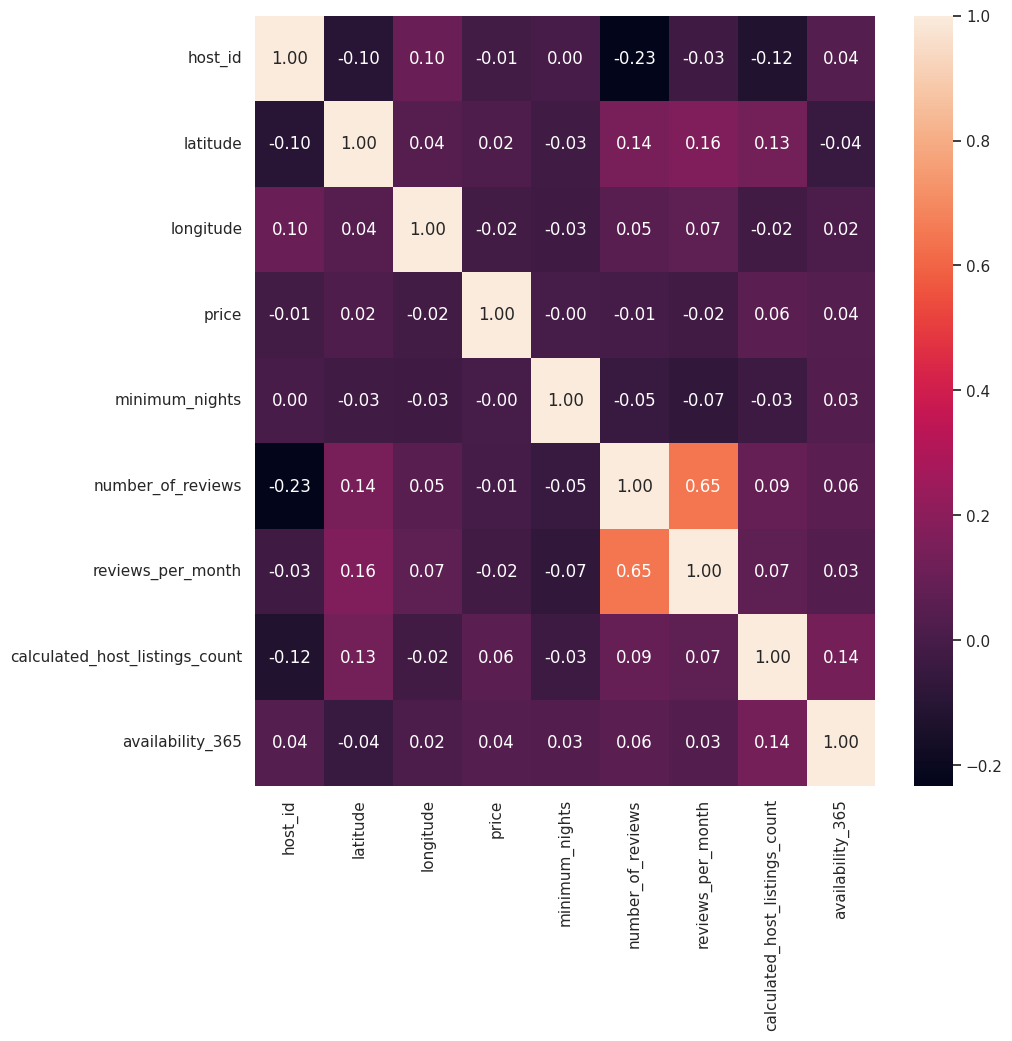

In [12]:
#get corelation between different variables
# Pearson correlation between different variables
## Is there a statistically significant relationship between any two variables?
## Which two variables have strongest relationship ? 
## Coorelation value affected by outliers.
## Useful observation:
## Positive relationship between latitude longitude and number of reviews
## Positive relationship between latitude longitude and reviews_per_month
## Positive relationship between price and calculated host listings count
## Negative relationship between price and number_of_reviews/reviews_per_month
## Positive relationship between calculated_host_listings_count and number_of_reviews/reviews_per_month
## Finally, higher positive relationship between number_of_reviews and reviews_per_month
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f');

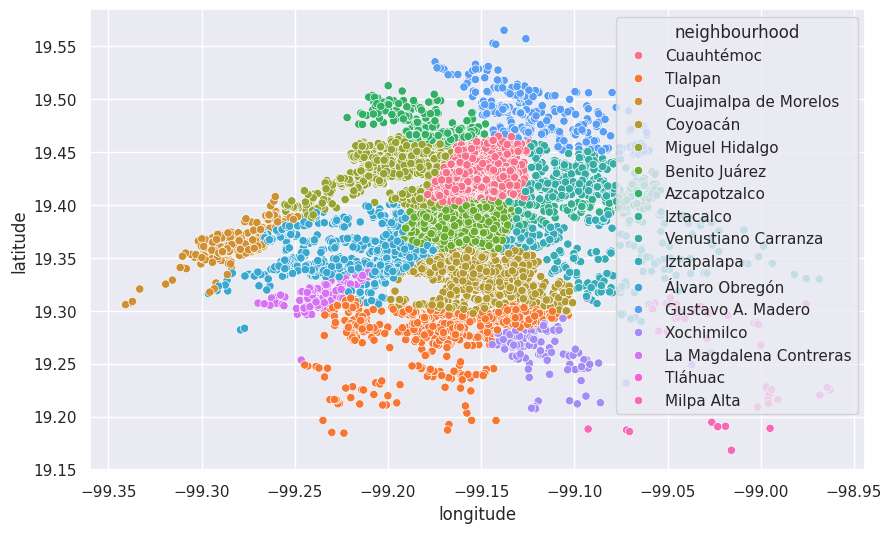

In [13]:
#the best way to visualize the longitude and the latitude along with the neighbourhood
#1. No association, there is no relationship between the longitude and latitude
#2. General purpose of this scatterplot: to map the naighbourhood in different longitude and latitude 
#3. We can conclude that Milpa Alta, Tlahuac, and Tlalpan neighbourhoods are a little further than the main mexico city
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.longitude, y=df.latitude, hue=df.neighbourhood)
plt.show()

Text(0.5, 1.0, 'Neighbourhood')

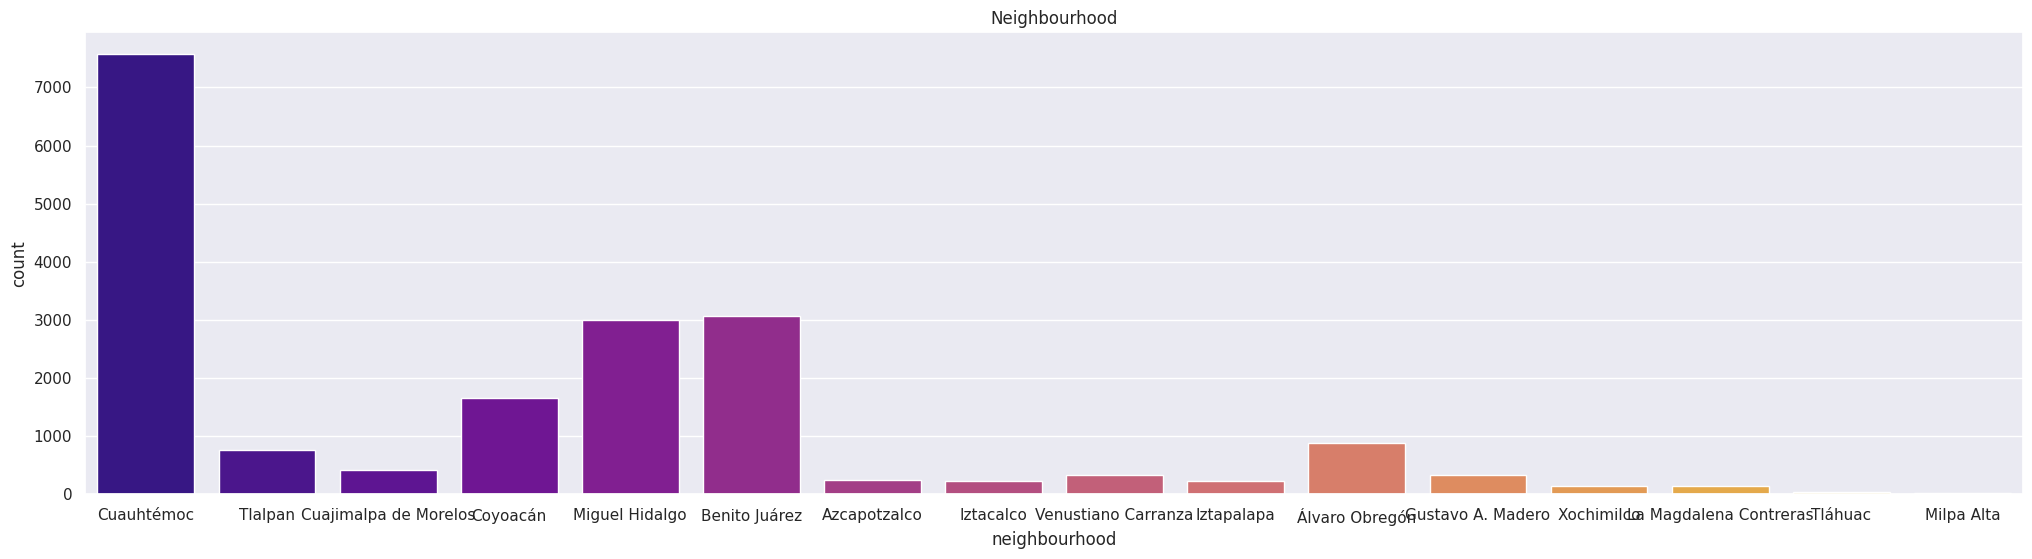

In [14]:
# Frequency graph showing listings of neighbourhood
#Cuahtemoc has the highest number of listings and Milpa Alta has the lowest number of listings
#Air bnbs in Cuahtemoc, Tlialpan, Coyacan, Miguel Hidalgo, and Alvaro Obregon have the maximum counts
sns.countplot(data=df, x='neighbourhood', hue='neighbourhood', palette="plasma", legend=False)
fig = plt.gcf()
fig.set_size_inches(25,6)
plt.title('Neighbourhood')

Text(0.5, 1.0, 'Neighbourhood')

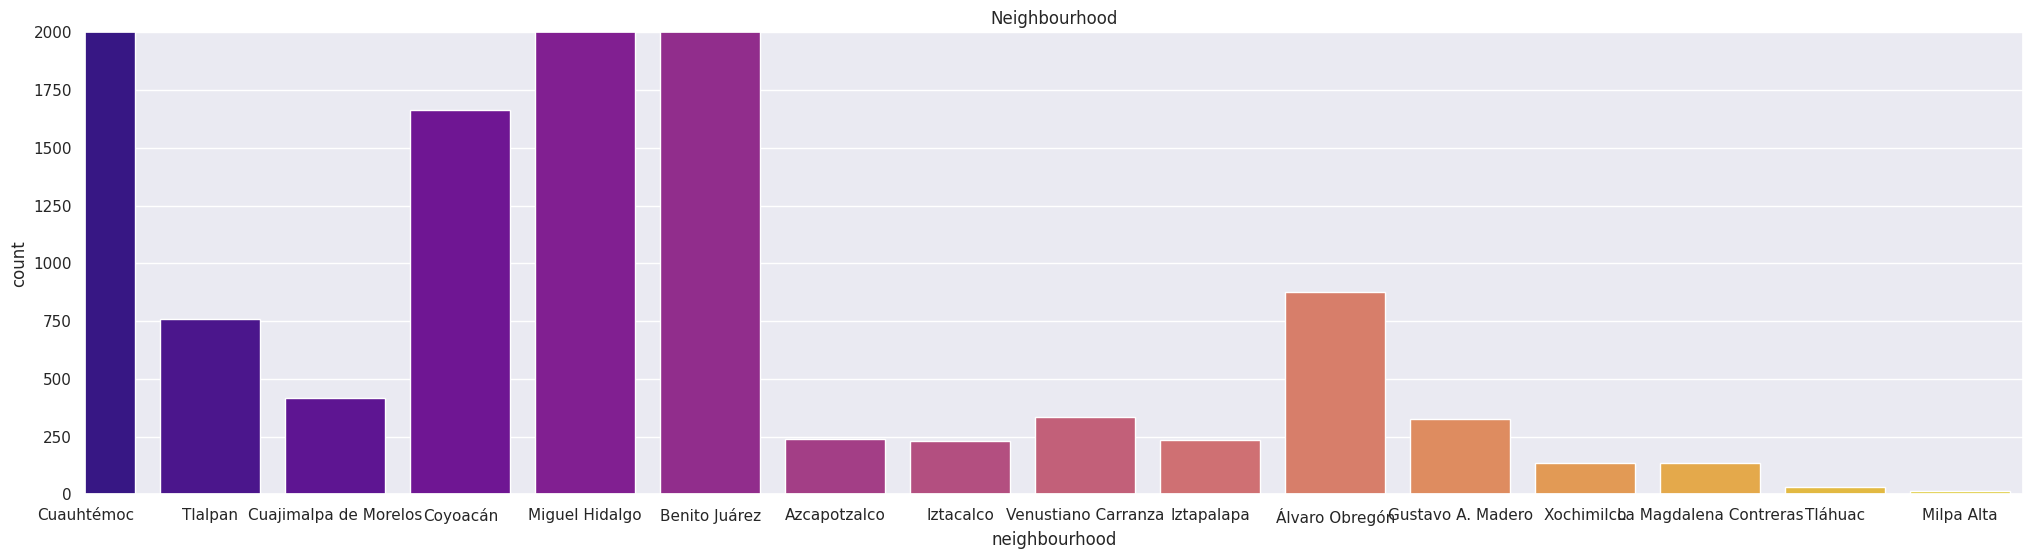

In [15]:
#Milpa Alta has the lowest number of listings which is less
sns.countplot(data=df, x='neighbourhood', hue='neighbourhood', palette="plasma", legend=False)
fig = plt.gcf()
plt.ylim(0, 2000)
plt.xlim(0, None)
fig.set_size_inches(25,6)
plt.title('Neighbourhood')

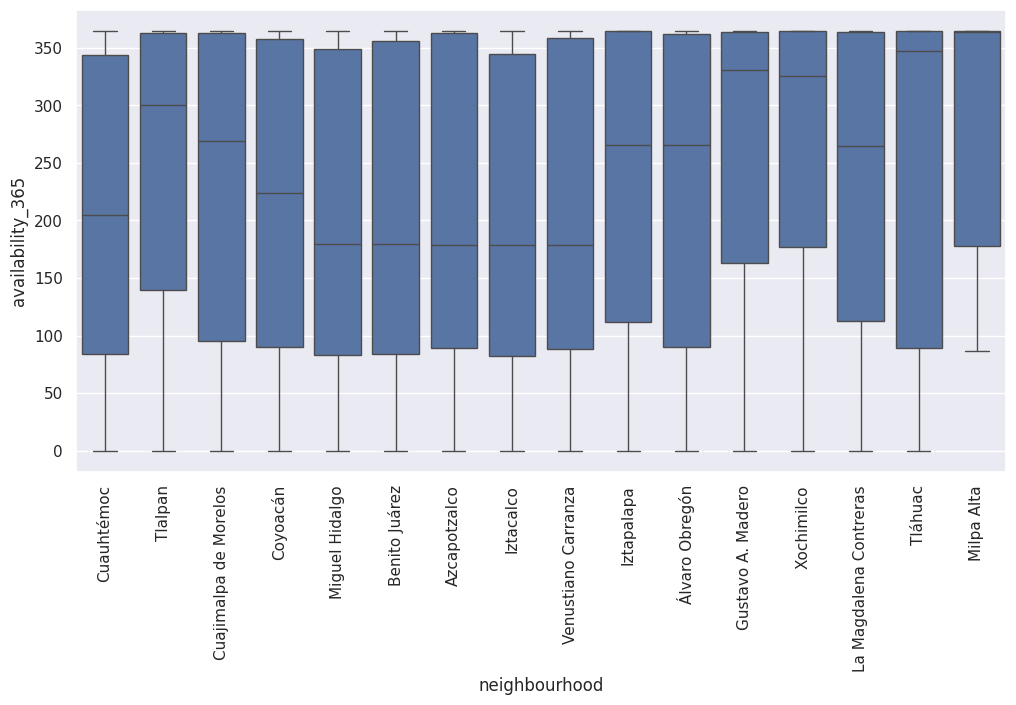

In [16]:
#box plotting neighbourhood and availability_365
# the median avialability of air bnbs in Miguel Hidalgo, Benito Juarez, Azcapotzalco,Iztacalco, and Venustiano Carranza is about the same, which
#means the air bnbs in these 5 locations are available upto 175 days in a year
#Even though Gustavo A.Madero, Xochimilco,  Tiahuac and Milpa Alta has significantly less number of 
#listings, they seem to have an median availability of more than 225 days per year.
#Cuauhtemoc being the main neighbourhood in the center of the city, has the highest listings but the median availability is around 200 days a year
plt.figure(figsize = (12, 6))
sns.boxplot(x = 'neighbourhood', y = 'availability_365',  data = df)
xt = plt.xticks(rotation=90)

['Private room' 'Entire home/apt' 'Shared room']


[Text(0, 0, 'Private room'),
 Text(1, 0, 'Entire home/apt'),
 Text(2, 0, 'Shared room')]

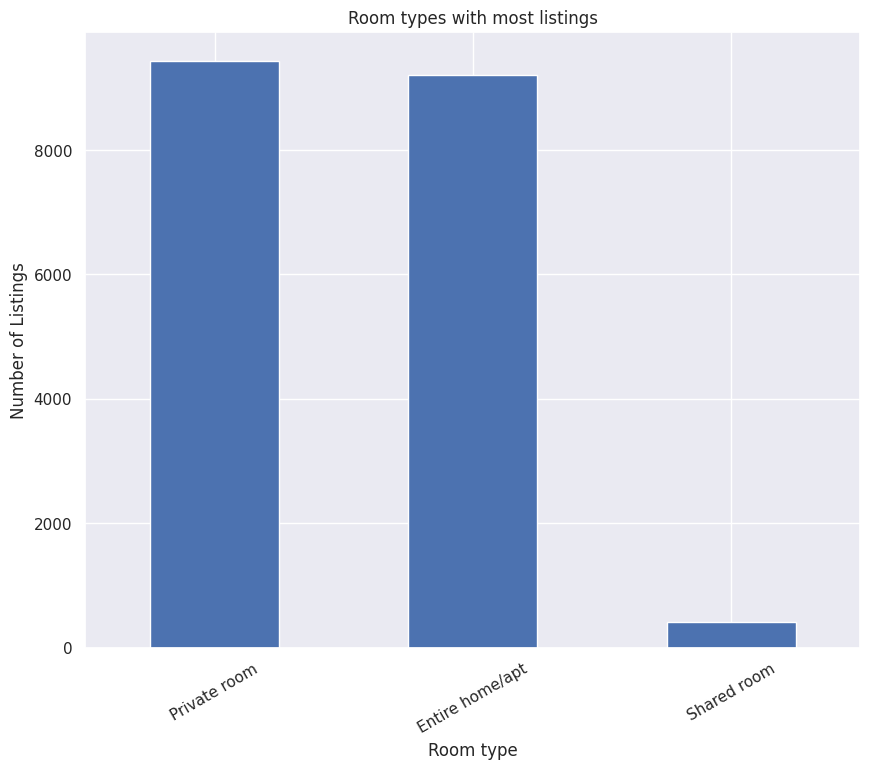

In [17]:
#List the occurences of different kinds of room_types.
#The three unique values of room type are : Private room, entire home/apart, and shared room
#Out of these three room types, private room and entire home/apart have more than 8000 listings while shared rooms have 
#less than 2000 listings

print(df.room_type.unique())
top_room_types = df.room_type.value_counts().head(5)
roomtype_listing_visualization = top_room_types.plot(kind='bar')
roomtype_listing_visualization.set_title('Room types with most listings')
roomtype_listing_visualization.set_ylabel('Number of Listings')
roomtype_listing_visualization.set_xlabel('Room type')
roomtype_listing_visualization.set_xticklabels(roomtype_listing_visualization.get_xticklabels(), rotation = 30)

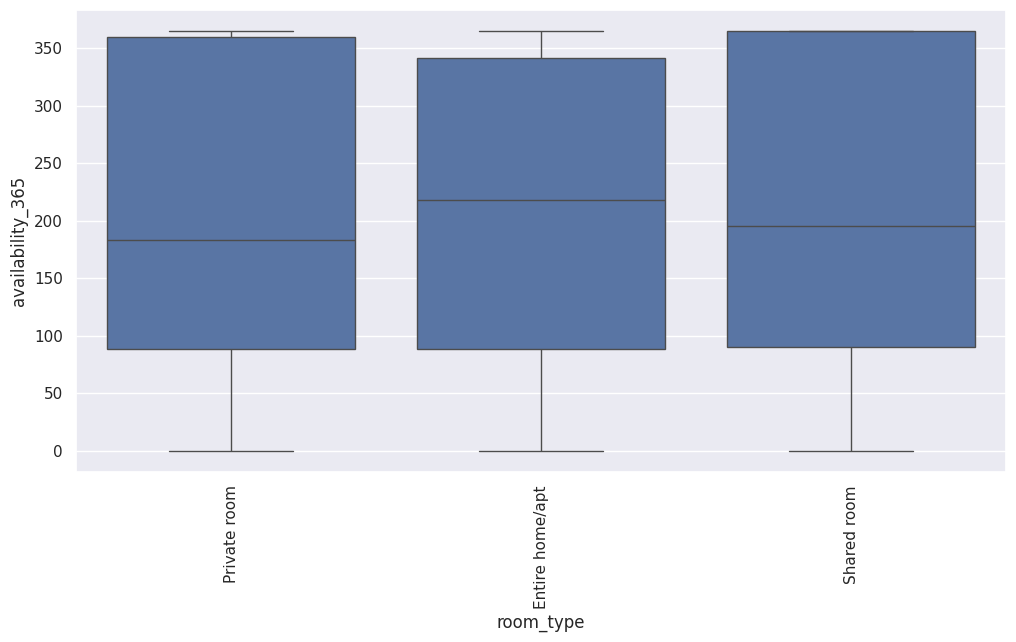

In [18]:
#The median availability of private rooms is upto 175 days per year
#The median availability of Entire home/apartment is upto 225 days per year
#The median availability of shared room is upto 180 days per year
#The median availability of entire home/apartment is comparatively greater than those of private rooms or shared rooms
plt.figure(figsize = (12, 6))
sns.boxplot(x = 'room_type', y = 'availability_365',  data = df)
xt = plt.xticks(rotation=90)

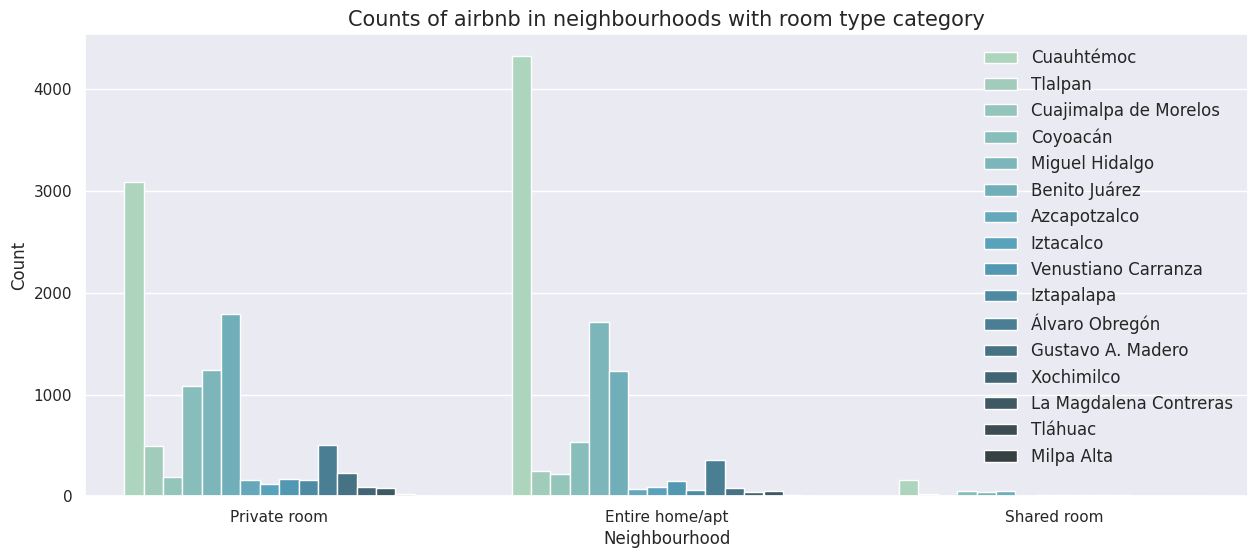

In [19]:
#plotting the neighbourhoods with different types of room
#Cuahtemoc seems to have the largest number of each type of rooms/housing
#Cuahtemoc has upto 3200 private rooms listings, 4700 entire home listings, and about 250 shared room listings

plt.figure(figsize=(15,6))
sns.countplot(x= df.room_type,hue=df.neighbourhood, palette='GnBu_d')
plt.title('Counts of airbnb in neighbourhoods with room type category', fontsize=15)
plt.xlabel('Neighbourhood')
plt.ylabel("Count")
plt.legend(frameon=False, fontsize=12)

([0, 1, 2],
 [Text(0, 0, 'Private room'),
  Text(1, 0, 'Entire home/apt'),
  Text(2, 0, 'Shared room')])

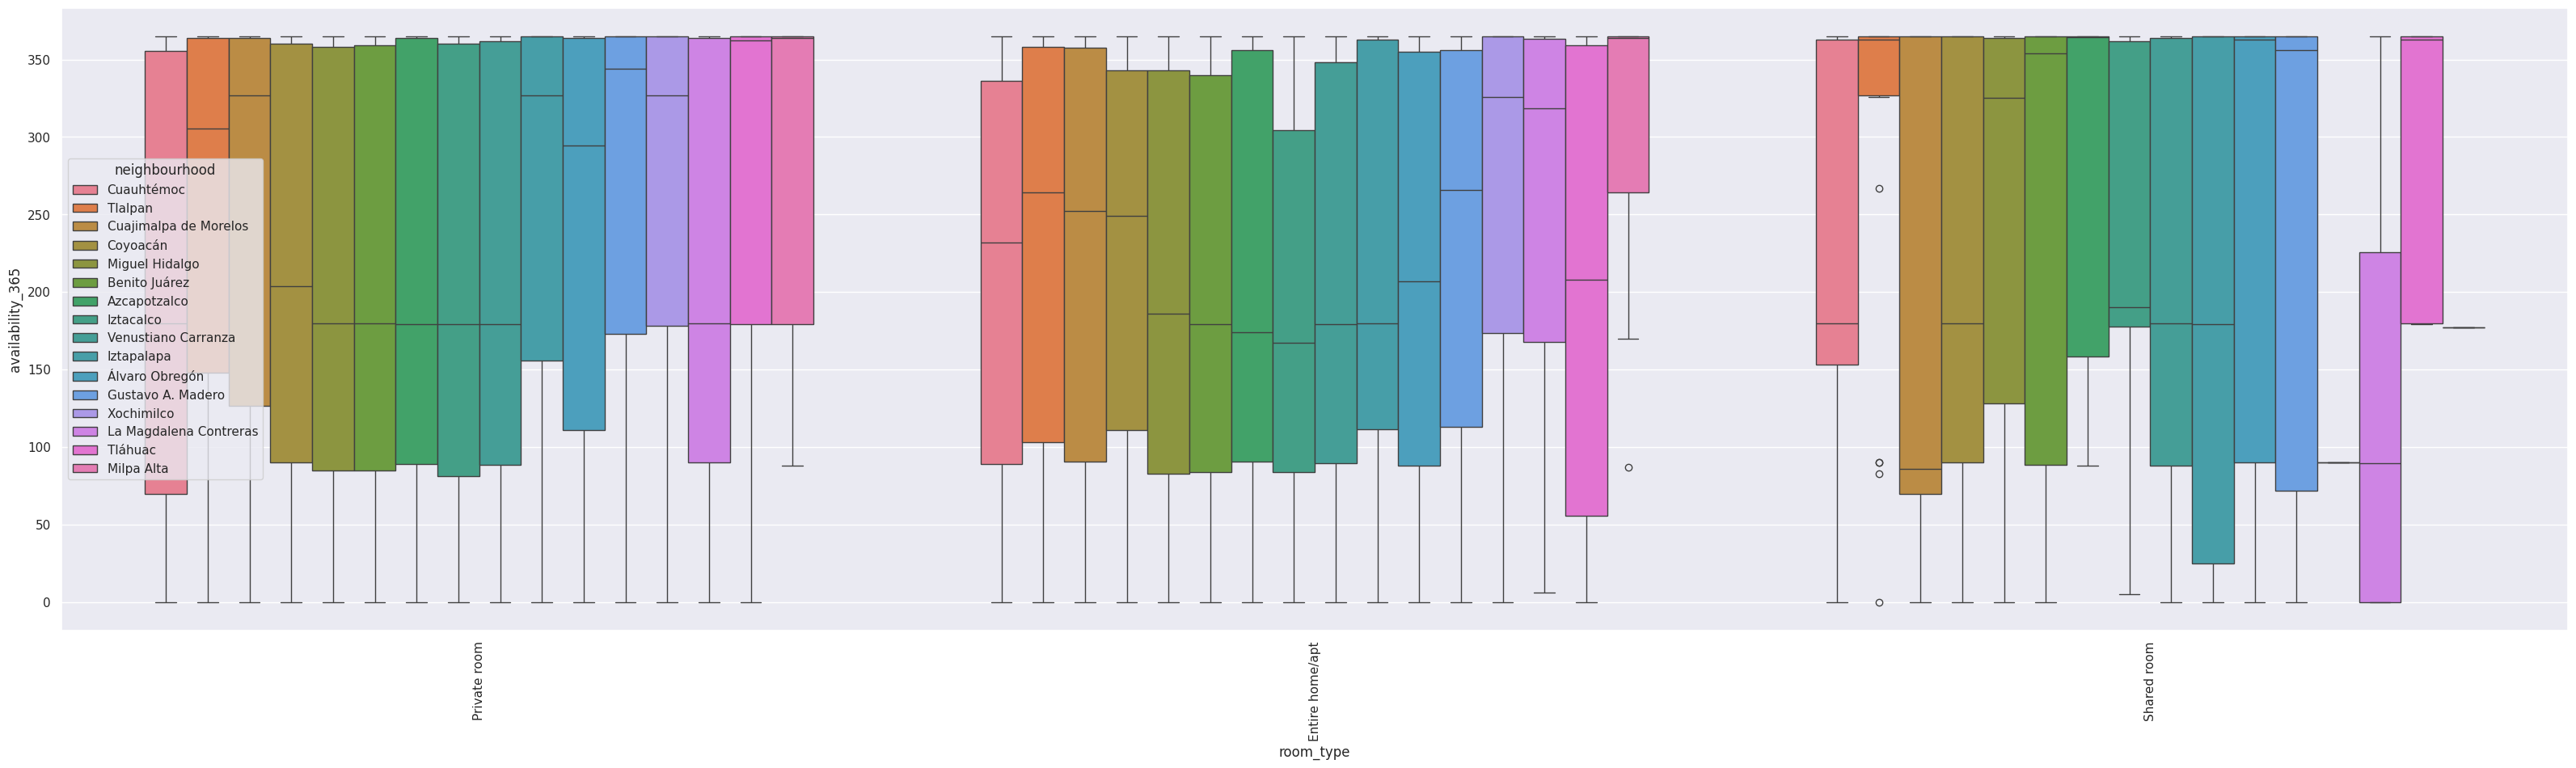

In [20]:
#The median availability of private room, entire home/apart, and shared room in Cuauhtemoc is between 180 to 220.
#We can conclude that the median availability of private room, entire home/apart, and shared room is the highest in Milpa Alta i.e more than 200
plt.figure(figsize = (40, 10))
xt = sns.boxplot(x = 'room_type', y = 'availability_365',hue = 'neighbourhood',  data = df)
xt = plt.xticks(rotation=90)
xt

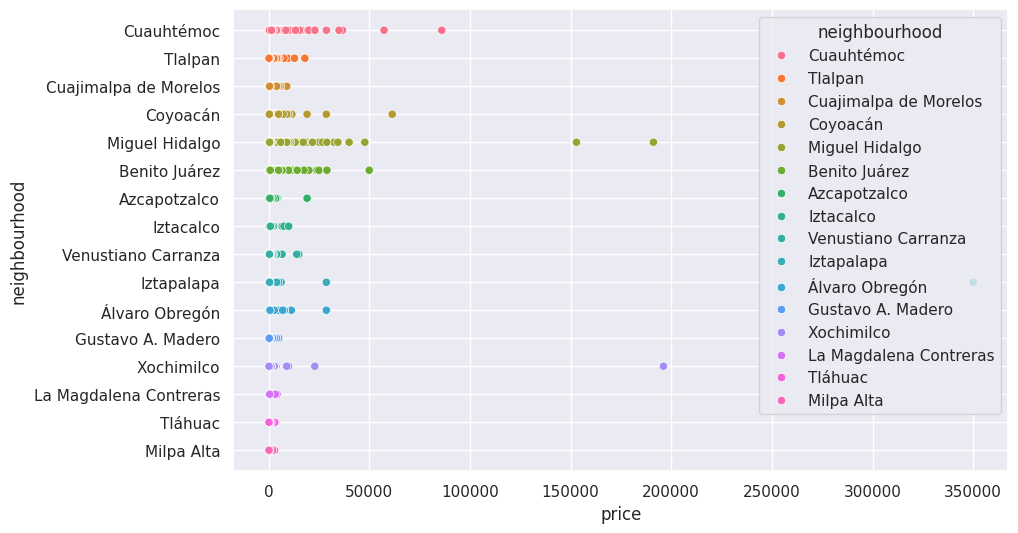

In [21]:
# Most of the housing options in each neighbourhood is between range 0-50000.
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.price, y=df.neighbourhood, hue=df.neighbourhood)
plt.show()

(0.0, 5000.0)

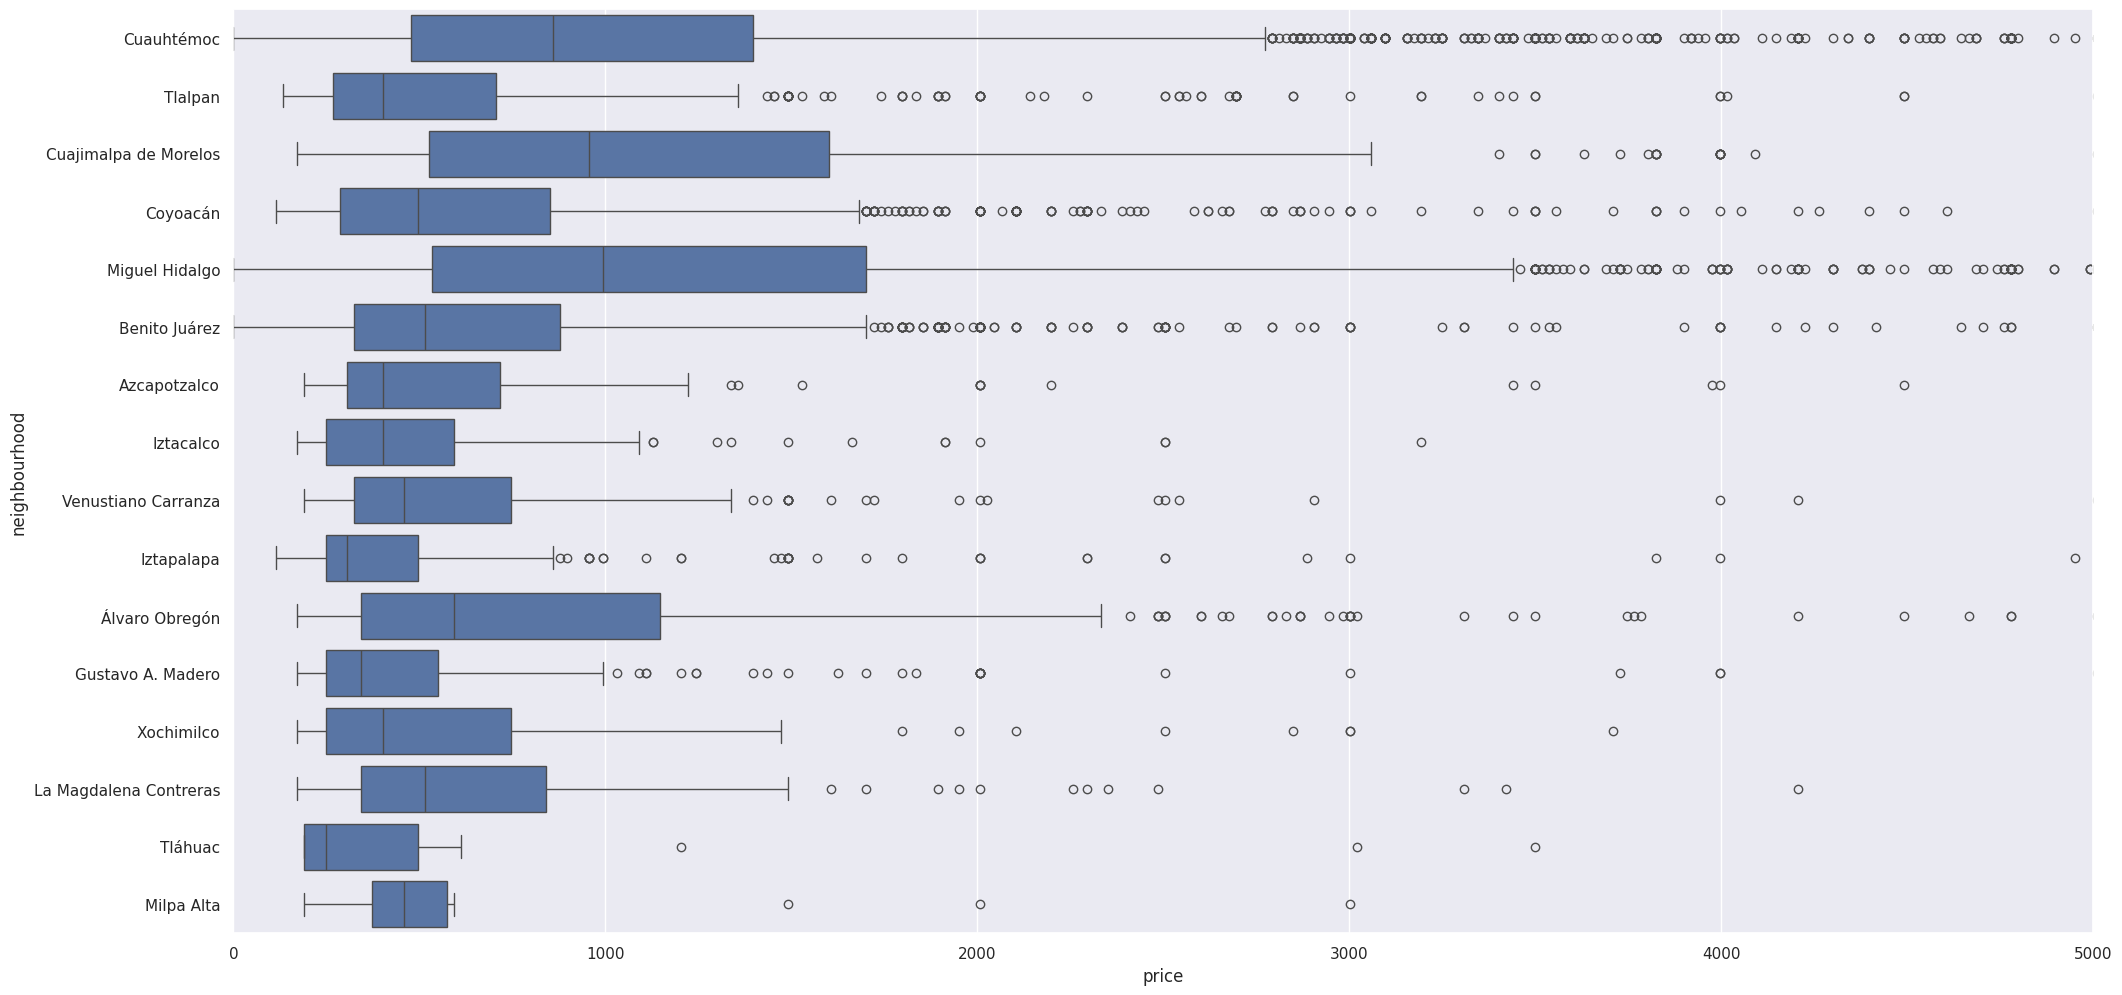

In [22]:
# Box plotting neighbourhood and price
plt.figure(figsize = (24, 12))
xt = sns.boxplot(x = 'price', y = 'neighbourhood',  data = df)
xt.set_xlim(0, 5000)

(0.0, 5000.0)

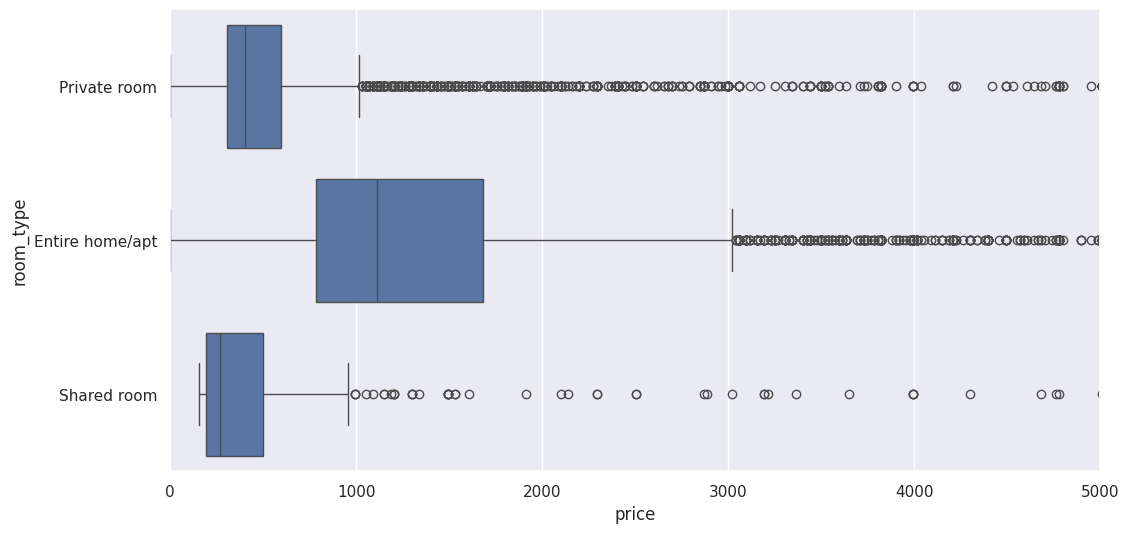

In [23]:
# Box plot showing prices of room_types
# 3rd quartile prices for private room and shared room fall below 1000
# Median price for entire home/apt seeems to be a little bit higher 1000
plt.figure(figsize = (12, 6))
xt = sns.boxplot(x = 'price'  , y = 'room_type',  data = df)
xt.set_xlim(0, 5000)

In [24]:
top_host = df.host_id.value_counts()
print(top_host.head(5))

host_id
4448934     45
42700394    44
10764020    44
10917267    43
5755202     40
Name: count, dtype: int64


In [25]:
check_top_host = df.calculated_host_listings_count.max()
print(check_top_host)

45


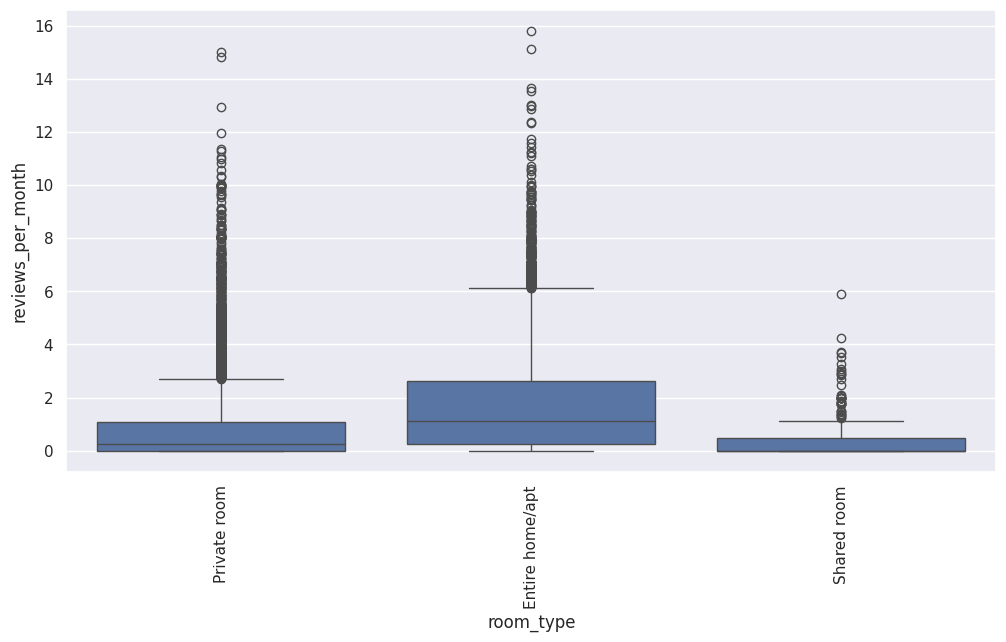

In [26]:
#box plotting room_type and reviews_per_month, helps us understand what kind of rooms get more reviews
#the median reviews_per_month for entire home/apt is the highest among all i.e 1
#Possible lowest review per month for entire home/apt is 1, and the highest is 6
plt.figure(figsize = (12, 6))
sns.boxplot(x = 'room_type', y = 'reviews_per_month',  data = df)
xt = plt.xticks(rotation=90)

Text(0.5, 1.0, 'minimum nights')

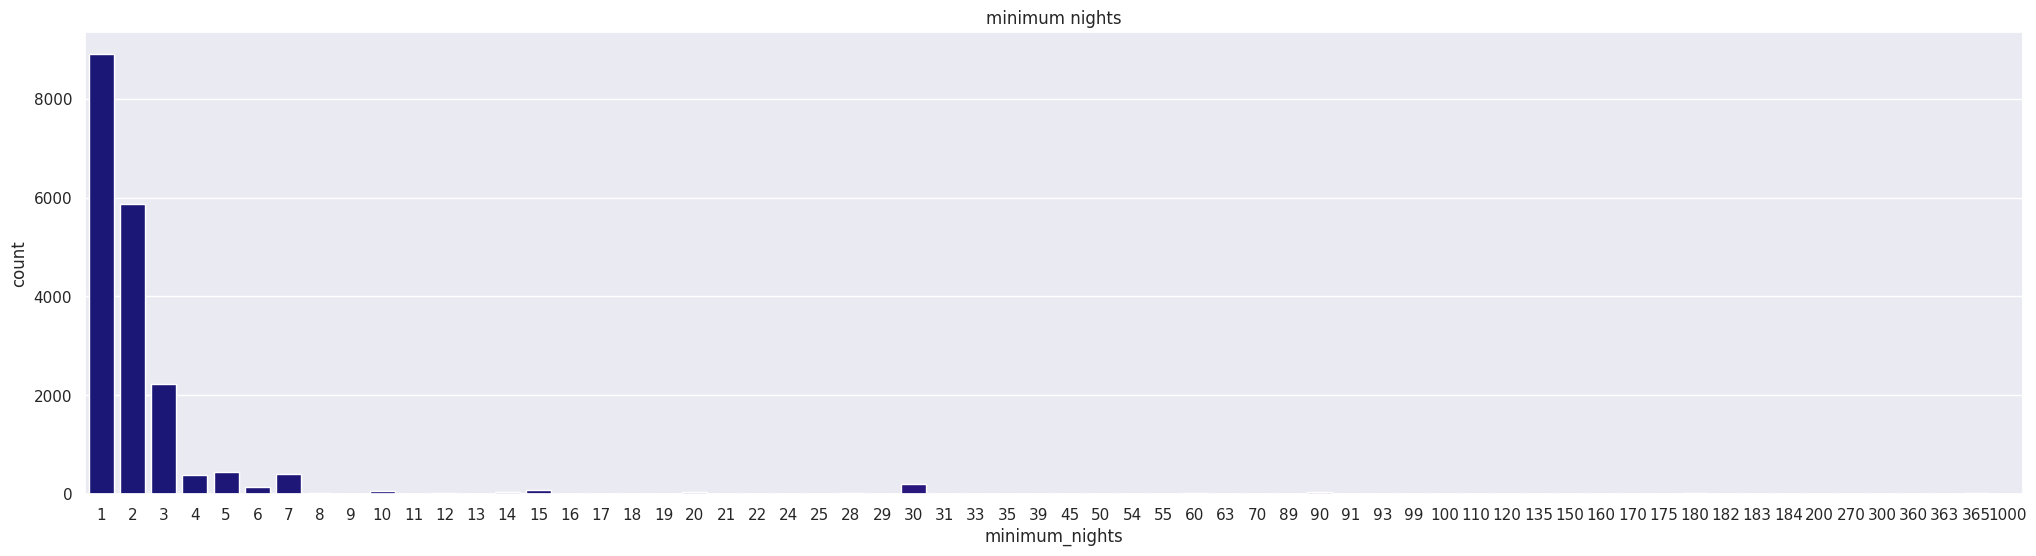

In [27]:
#We used countplot to find the number of listings for minimum nights 
#there are more than 8000 listings for a minimum night of 1
#we can conclude that it is easier to find a room for a minimum of 1 day than a minimum of 30 days
sns.countplot(data=df, x='minimum_nights', hue='minimum_nights', palette="plasma", legend=False)
fig = plt.gcf()
fig.set_size_inches(25,6)
plt.title('minimum nights')

In [28]:
df.head(5)

,name,host_id,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Private room c/ bathroom . Colonia Juarez.,57785,Cuauhtémoc,19.43035,-99.15511,Private room,478,2,0,0.00,2,327
1,"Sunny suite w/ queen size bed, inside boutique...",87973,Cuauhtémoc,19.44076,-99.16324,Private room,1969,1,57,0.52,9,355
2,Couple of Rooms,145672,Tlalpan,19.27215,-99.21848,Private room,1740,1,0,0.00,1,365
3,Villa Dante,153786,Cuajimalpa de Morelos,19.38399,-99.27335,Entire home/apt,3823,1,0,0.00,2,363
4,CONDESA HAUS B&B,196253,Cuauhtémoc,19.41006,-99.17645,Private room,1893,1,39,0.42,10,334


In [31]:
df = pd.read_csv("/kaggle/input/datasets/shree5niraj/listings1/listings1.csv")
df = df[(df.price > 0) & (df.price <= 2000)].copy()

cat = ["neighbourhood", "room_type"]
num = ["minimum_nights", "number_of_reviews", "availability_365", "latitude", "longitude"]
X, y = df[cat + num], df["price"]
print(X.shape)
y.describe()

(16950, 7)


count    16950.000000
mean       725.183717
std        446.247674
min         38.000000
25%        344.000000
50%        593.000000
75%        994.000000
max       1988.000000
Name: price, dtype: float64

In [32]:
import numpy as np
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate

def make_pipe(model):
    pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)],
                            remainder="passthrough")
    return Pipeline([("pre", pre),
                     ("model", TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1))])

models = {"baseline (median)": DummyRegressor(strategy="median"),
          "random forest": RandomForestRegressor(n_estimators=300, random_state=1, n_jobs=-1),
          "gradient boosting": HistGradientBoostingRegressor(random_state=1)}
cv = KFold(n_splits=5, shuffle=True, random_state=1)

rows = []
for name, model in models.items():
    s = cross_validate(make_pipe(model), X, y, cv=cv,
                       scoring=("neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"))
    rows.append({"model": name,
                 "MAE": -s["test_neg_mean_absolute_error"].mean(),
                 "RMSE": -s["test_neg_root_mean_squared_error"].mean(),
                 "R2": s["test_r2"].mean()})
results = pd.DataFrame(rows).set_index("model").round(2)
results

,MAE,RMSE,R2
model,,,
baseline (median),356.62,465.37,-0.09
random forest,212.99,305.11,0.53
gradient boosting,218.29,311.68,0.51


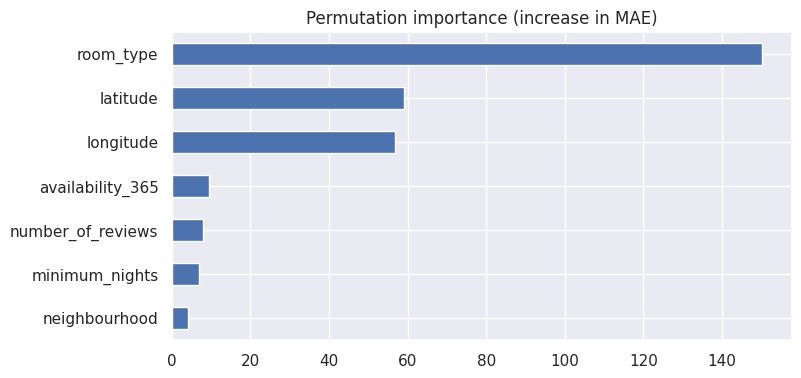

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
best = make_pipe(RandomForestRegressor(n_estimators=300, random_state=1, n_jobs=-1)).fit(X_train, y_train)

imp = permutation_importance(best, X_test, y_test, scoring="neg_mean_absolute_error",
                             n_repeats=10, random_state=1)
importance = pd.Series(imp.importances_mean, index=X.columns).sort_values()
importance.plot(kind="barh", figsize=(8, 4), title="Permutation importance (increase in MAE)")
plt.show()

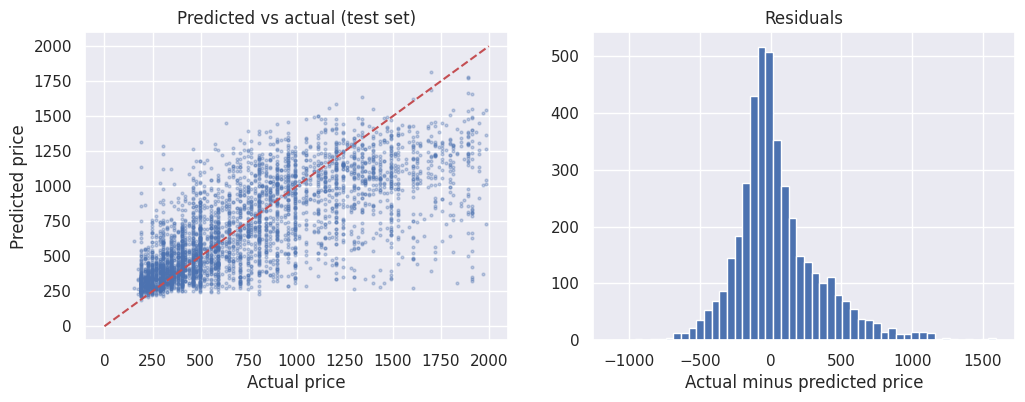

In [34]:
pred = best.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_test, pred, s=4, alpha=0.3)
ax[0].plot([0, 2000], [0, 2000], "r--")
ax[0].set(xlabel="Actual price", ylabel="Predicted price", title="Predicted vs actual (test set)")
ax[1].hist(y_test - pred, bins=50)
ax[1].set(xlabel="Actual minus predicted price", title="Residuals")
plt.show()